# Handling Missing Values in Time Series: Forward Fill, Backfill, and Interpolation

Missing values are common in time series work. They often appear when we reindex data, resample to a new frequency, or merge datasets from different sources.

In finance, stock prices usually have gaps on weekends and market holidays because trading does not happen every calendar day. In this lesson we will create those gaps on purpose and then handle them with forward fill, backfill, and interpolation.

## 1) Imports

We use `pandas` for time series handling, `numpy` for simple numeric work, and `matplotlib` for charts.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.options.display.float_format = '{:,.2f}'.format
pd.options.display.max_rows = 20
plt.style.use('default')

## 2) Create Example Stock Price Data

We will build a small stock-price dataset using only business days. That means weekends are excluded from the index, which is exactly how many trading datasets behave.

We also add two calendar-style fields, `day` and `quarter`, to show how date features can be recomputed after reindexing.

In [2]:
# Business-day index: weekends are automatically excluded.
business_days = pd.bdate_range(start='2024-01-02', end='2024-01-19')

stock_data = pd.DataFrame(
    {
        'Apple': [189.50, 191.20, 190.70, 193.10, 194.40, 195.00, 196.30, 195.90, 197.10, 198.40, 199.20, 200.10, 201.40, 202.00],
        'Boeing': [221.40, 222.10, 220.80, 223.60, 224.30, 225.10, 224.60, 226.20, 227.00, 226.50, 228.40, 229.10, 230.30, 231.00],
        'Microsoft': [371.20, 372.40, 371.90, 374.10, 375.60, 376.20, 377.50, 378.10, 379.40, 380.00, 381.80, 382.40, 383.60, 384.20],
    },
    index=business_days,
)

stock_data.index.name = 'Date'
stock_data['day'] = stock_data.index.day_name()
stock_data['quarter'] = stock_data.index.quarter

print('Head:')
print(stock_data.head())
print('\nTail:')
print(stock_data.tail())

Head:
            Apple  Boeing  Microsoft        day  quarter
Date                                                    
2024-01-02 189.50  221.40     371.20    Tuesday        1
2024-01-03 191.20  222.10     372.40  Wednesday        1
2024-01-04 190.70  220.80     371.90   Thursday        1
2024-01-05 193.10  223.60     374.10     Friday        1
2024-01-08 194.40  224.30     375.60     Monday        1

Tail:
            Apple  Boeing  Microsoft        day  quarter
Date                                                    
2024-01-15 198.40  226.50     380.00     Monday        1
2024-01-16 199.20  228.40     381.80    Tuesday        1
2024-01-17 200.10  229.10     382.40  Wednesday        1
2024-01-18 201.40  230.30     383.60   Thursday        1
2024-01-19 202.00  231.00     384.20     Friday        1


Trading data often omits weekends and holidays. That is not an error. It simply reflects that markets were closed and no new traded closing price was recorded.

## 3) Reindex to All Calendar Days

Now we create a full daily date range from the first date to the last date and reindex the stock data to that full calendar.

This introduces `NaN` values on non-trading days because those dates did not exist in the original business-day dataset.

In [3]:
price_columns = ['Apple', 'Boeing', 'Microsoft']
full_daily_index = pd.date_range(start=stock_data.index.min(), end=stock_data.index.max(), freq='D')

stock_calendar = stock_data[price_columns].reindex(full_daily_index)
stock_calendar.index.name = 'Date'
stock_calendar['day'] = stock_calendar.index.day_name()
stock_calendar['quarter'] = stock_calendar.index.quarter

print(stock_calendar.loc['2024-01-05':'2024-01-09'])

            Apple  Boeing  Microsoft       day  quarter
Date                                                   
2024-01-05 193.10  223.60     374.10    Friday        1
2024-01-06    NaN     NaN        NaN  Saturday        1
2024-01-07    NaN     NaN        NaN    Sunday        1
2024-01-08 194.40  224.30     375.60    Monday        1
2024-01-09 195.00  225.10     376.20   Tuesday        1


The `NaN` values above were created by the reindexing step. Saturday and Sunday now exist in the index, but there were no observed stock prices for those dates in the original dataset.

## 4) Fill Missing Values with Backfill

Backfill (`bfill`) uses the **next valid observation** to fill missing values.

This can be useful in some workflows, but it is usually less natural for stock prices because it pulls future information backward in time.

In [4]:
stock_bfill = stock_calendar.copy()
stock_bfill[price_columns] = stock_bfill[price_columns].bfill()

print(stock_bfill.loc['2024-01-05':'2024-01-09'])

            Apple  Boeing  Microsoft       day  quarter
Date                                                   
2024-01-05 193.10  223.60     374.10    Friday        1
2024-01-06 194.40  224.30     375.60  Saturday        1
2024-01-07 194.40  224.30     375.60    Sunday        1
2024-01-08 194.40  224.30     375.60    Monday        1
2024-01-09 195.00  225.10     376.20   Tuesday        1


## 5) Fill Missing Values with Forward Fill

Forward fill (`ffill`) uses the **previous valid observation** to fill missing values.

For stock prices, this is usually more appropriate because the last observed market price remains the most recent known price until a new trade updates it.

In [5]:
stock_ffill = stock_calendar.copy()
stock_ffill[price_columns] = stock_ffill[price_columns].ffill()

print(stock_ffill.loc['2024-01-05':'2024-01-09'])

            Apple  Boeing  Microsoft       day  quarter
Date                                                   
2024-01-05 193.10  223.60     374.10    Friday        1
2024-01-06 193.10  223.60     374.10  Saturday        1
2024-01-07 193.10  223.60     374.10    Sunday        1
2024-01-08 194.40  224.30     375.60    Monday        1
2024-01-09 195.00  225.10     376.20   Tuesday        1


## 6) Save the Filled Result

A common pattern is to assign the filled result back to a new DataFrame. This keeps the original version available for comparison and avoids inplace-style side effects.

In [6]:
stock_complete_daily = stock_calendar.copy()
stock_complete_daily[price_columns] = stock_complete_daily[price_columns].ffill()

print('Missing values before fill:')
print(stock_calendar[price_columns].isna().sum())
print('\nMissing values after fill:')
print(stock_complete_daily[price_columns].isna().sum())

Missing values before fill:
Apple        4
Boeing       4
Microsoft    4
dtype: int64

Missing values after fill:
Apple        0
Boeing       0
Microsoft    0
dtype: int64


## 7) Reindex and Fill in One Step

Instead of reindexing first and filling second, pandas can also fill missing values during the reindex operation itself.

Both approaches are valid. The two-step version is easier to inspect when teaching or debugging, while the one-step version is concise.

In [7]:
stock_one_step_ffill = stock_data[price_columns].reindex(full_daily_index, method='ffill')
stock_one_step_ffill.index.name = 'Date'

same_prices = stock_one_step_ffill.equals(stock_complete_daily[price_columns])

print('One-step result around the weekend:')
print(stock_one_step_ffill.loc['2024-01-05':'2024-01-09'])
print(f'\nDo the one-step and two-step price results match? {same_prices}')

One-step result around the weekend:
            Apple  Boeing  Microsoft
Date                                
2024-01-05 193.10  223.60     374.10
2024-01-06 193.10  223.60     374.10
2024-01-07 193.10  223.60     374.10
2024-01-08 194.40  224.30     375.60
2024-01-09 195.00  225.10     376.20

Do the one-step and two-step price results match? True


## 8) Create an Example Temperature Dataset

Interpolation is usually more appropriate for continuous measurements such as temperature, sensor readings, or humidity.

Here we create hourly temperature data for Los Angeles and New York.

In [8]:
hourly_index = pd.date_range(start='2024-02-01 08:00', end='2024-02-01 18:00', freq='h')

temperature_data = pd.DataFrame(
    {
        'Los Angeles': [16.0, 16.5, 17.2, 18.4, 19.3, 20.1, 20.6, 20.0, 19.1, 18.2, 17.4],
        'New York': [2.5, 3.0, 4.2, 5.8, 7.4, 8.3, 8.8, 8.1, 7.0, 5.9, 4.8],
    },
    index=hourly_index,
)

temperature_data.index.name = 'Timestamp'
print(temperature_data)

                     Los Angeles  New York
Timestamp                                 
2024-02-01 08:00:00        16.00      2.50
2024-02-01 09:00:00        16.50      3.00
2024-02-01 10:00:00        17.20      4.20
2024-02-01 11:00:00        18.40      5.80
2024-02-01 12:00:00        19.30      7.40
2024-02-01 13:00:00        20.10      8.30
2024-02-01 14:00:00        20.60      8.80
2024-02-01 15:00:00        20.00      8.10
2024-02-01 16:00:00        19.10      7.00
2024-02-01 17:00:00        18.20      5.90
2024-02-01 18:00:00        17.40      4.80


## 9) Upsample Temperature Data to 30-Minute Frequency

Upsampling means moving to a higher frequency. When we resample hourly data to 30-minute intervals, pandas creates new timestamps between the original observations.

Those intermediate timestamps do not yet have data, so they appear as missing values.

In [9]:
temperature_30min = temperature_data.resample('30min').mean()

print(temperature_30min.head(8))

                     Los Angeles  New York
Timestamp                                 
2024-02-01 08:00:00        16.00      2.50
2024-02-01 08:30:00          NaN       NaN
2024-02-01 09:00:00        16.50      3.00
2024-02-01 09:30:00          NaN       NaN
2024-02-01 10:00:00        17.20      4.20
2024-02-01 10:30:00          NaN       NaN
2024-02-01 11:00:00        18.40      5.80
2024-02-01 11:30:00          NaN       NaN


## 10) Interpolate Missing Values

Interpolation estimates values between known observations. This often makes sense for continuous data because the underlying variable usually changes smoothly rather than jumping only at the observed timestamps.

In [10]:
temperature_interpolated = temperature_30min.interpolate()

print(temperature_interpolated.head(8))

                     Los Angeles  New York
Timestamp                                 
2024-02-01 08:00:00        16.00      2.50
2024-02-01 08:30:00        16.25      2.75
2024-02-01 09:00:00        16.50      3.00
2024-02-01 09:30:00        16.85      3.60
2024-02-01 10:00:00        17.20      4.20
2024-02-01 10:30:00        17.80      5.00
2024-02-01 11:00:00        18.40      5.80
2024-02-01 11:30:00        18.85      6.60


## 11) Visual Comparison

To keep the chart readable, we focus on Los Angeles. The same interpolation logic applies to both cities.

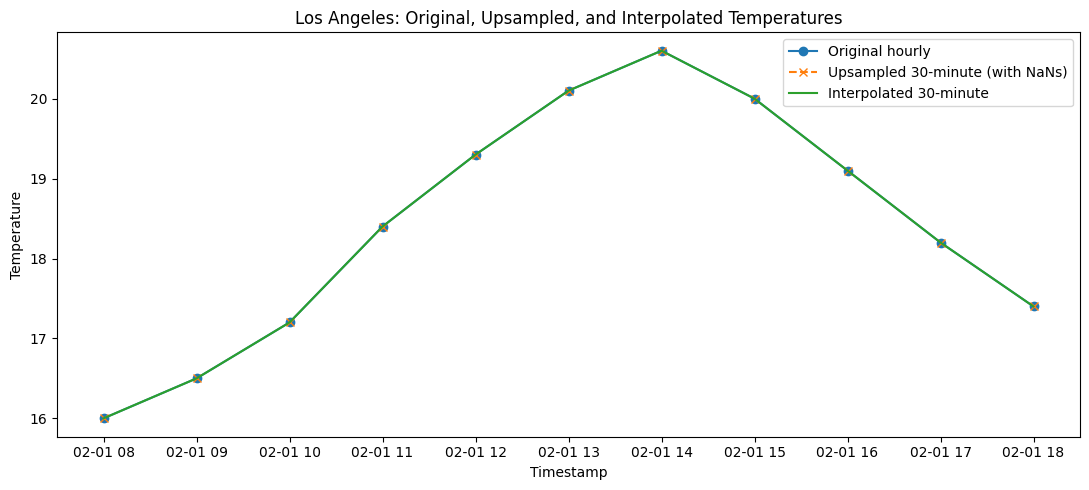

In [11]:
selected_city = 'Los Angeles'

plt.figure(figsize=(11, 5))
plt.plot(temperature_data.index, temperature_data[selected_city], marker='o', label='Original hourly')
plt.plot(temperature_30min.index, temperature_30min[selected_city], marker='x', linestyle='--', label='Upsampled 30-minute (with NaNs)')
plt.plot(temperature_interpolated.index, temperature_interpolated[selected_city], label='Interpolated 30-minute')
plt.title(f'{selected_city}: Original, Upsampled, and Interpolated Temperatures')
plt.xlabel('Timestamp')
plt.ylabel('Temperature')
plt.legend()
plt.tight_layout()
plt.show()

## Key Takeaways

- Reindexing can create missing values when you add dates or times that were not present in the original data.
- Resampling can also create missing values, especially when you upsample to a finer frequency.
- Forward fill is typically the most natural choice for stock prices because it carries the last known traded value forward.
- Backfill can be useful in some workflows, but it uses future observations and should be applied carefully.
- Interpolation is often better for continuous measurements such as temperature because it estimates values between known points.

## Optional Practice

Try the following exercises:
- Reindex another price series to include calendar days and inspect where missing values appear.
- Compare `bfill()` and `ffill()` on the same stock-price window and decide which feels more realistic.
- Create another continuous dataset, such as rainfall or electricity usage, and test whether interpolation produces sensible intermediate values.